In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import config
from src import *

# **1. Download data**

In [2]:
tickers = config.tickers
data = DataLoader(tickers)
data.download_data(start_date = config.start_date, end_date = config.end_date)

[*********************100%***********************]  100 of 100 completed


Price        Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2010-01-04    6.418381         NaN   18.321968   37.090000   25.670000   
2010-01-05    6.429480         NaN   18.173944   37.700001   25.280001   
2010-01-06    6.327210         NaN   18.274872   37.619999   25.340000   
2010-01-07    6.315514         NaN   18.426273   36.889999   25.480000   
2010-01-08    6.357500         NaN   18.520466   36.689999   26.260000   
...                ...         ...         ...         ...         ...   
2025-10-06  256.441406  226.718292  132.476868  350.140015  323.429993   
2025-10-07  256.231628  229.318466  131.763672  348.309998  314.190002   
2025-10-08  257.810089  227.752457  133.001862  348.769989  311.410004   
2025-10-09  253.793961  227.210754  132.050919  347.470001  310.320007   
2025-10-10  245.032471  227.023605  131.317917  337.510010  303.500000   

Price                                                                    ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2010-01-04    9.700000   39.311684    6.695000   51.433220    32.425720  ...   
2010-01-05    9.710000   38.971138    6.734500   51.006466    32.678314  ...   
2010-01-06    9.570000   38.678280    6.612500   50.585888    32.977695  ...   
2010-01-07    9.470000   38.324123    6.500000   50.295200    32.060860  ...   
2010-01-08    9.430000   38.664646    6.676000   50.616821    31.293720  ...   
...                ...         ...         ...         ...          ...  ...   
2025-10-06  203.710007  292.037079  220.899994  268.986603  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  268.927032  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  266.633759   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  260.806305   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  255.217087   934.531982  ...   

Price           Volume                                                   \
Ticker            UBER       UL       UNH       UPS         V       WFC   
Date                                                                      
2010-01-04         NaN   709690  12199500   3897200  20180000  39335700   
2010-01-05         NaN   825396  11180700   5966300  25833600  55416000   
2010-01-06         NaN  1608701   9761100   5770200  16254000  33237000   
2010-01-07         NaN  1212386  11789800   5747000  27841200  61649000   
2010-01-08         NaN   676390   7228700  13779300  11907200  35508700   
...                ...      ...       ...       ...       ...       ...   
2025-10-06  22760900.0  1801397   7181700   6987000   4735600  12837700   
2025-10-07  12583600.0  1941701   7236200   4726800   5044600  10371300   
2025-10-08  10071200.0  1617314   9438300   4896000   3927500  11277400   
2025-10-09  13435700.0  2237760   8759800   5784700   4434800   8432200   
2025-10-10  17021100.0  4715990  13141900   8506000   6296200  16004300   

Price                                               
Ticker           WMT       XOM        XYZ      YUM  
Date                                                
2010-01-04  62259300  27809100        NaN  2962274  
2010-01-05  46945200  30174700        NaN  3298757  
2010-01-06  37551600  35044700        NaN  4178981  
2010-01-07  31988100  27192100        NaN  2452472  
2010-01-08  34089600  24891800        NaN  3772392  
...              ...       ...        ...      ...  
2025-10-06  13303600  12036800  5324100.0  1395000  
2025-10-07  15538900  11945000  5428000.0  1657100  
2025-10-08  13584100  12301000  6024900.0  1150600  
2025-10-09  19508000  10976200  4193600.0  1371000  
2025-10-10  18519400  13811600  8802300.0  2055300  

[3968 rows x 600 columns]

In [3]:
data.save_df(filename='price_volume_data.csv')

# **2. Data Preparation and Oulier Handling**

In [4]:
data = pd.read_csv("price_volume_data.csv", header=[0, 1], index_col=0, parse_dates=True)
data.head()

Price      Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418381  NaN  18.321968  37.090000  25.670000  9.70  39.311684   
2010-01-05  6.429480  NaN  18.173944  37.700001  25.280001  9.71  38.971138   
2010-01-06  6.327210  NaN  18.274872  37.619999  25.340000  9.57  38.678280   
2010-01-07  6.315514  NaN  18.426273  36.889999  25.480000  9.47  38.324123   
2010-01-08  6.357500  NaN  18.520466  36.689999  26.260000  9.43  38.664646   

Price                                     ... Volume                     \
Ticker        AMZN        APD       ASML  ...   UBER       UL       UNH   
Date                                      ...                             
2010-01-04  6.6950  51.433220  32.425720  ...    NaN   709690  12199500   
2010-01-05  6.7345  51.006466  32.678314  ...    NaN   825396  11180700   
2010-01-06  6.6125  50.585888  32.977695  ...    NaN  1608701   9761100   
2010-01-07  6.5000  50.295200  32.060860  ...    NaN  1212386  11789800   
2010-01-08  6.6760  50.616821  31.293720  ...    NaN   676390   7228700   

Price                                                                      
Ticker           UPS         V       WFC       WMT       XOM XYZ      YUM  
Date                                                                       
2010-01-04   3897200  20180000  39335700  62259300  27809100 NaN  2962274  
2010-01-05   5966300  25833600  55416000  46945200  30174700 NaN  3298757  
2010-01-06   5770200  16254000  33237000  37551600  35044700 NaN  4178981  
2010-01-07   5747000  27841200  61649000  31988100  27192100 NaN  2452472  
2010-01-08  13779300  11907200  35508700  34089600  24891800 NaN  3772392  

[5 rows x 600 columns]

In [5]:
prepare = DataProcessor("price_volume_data.csv")

# for ticker in prepare.tickers:
#     prepare.check_na(ticker)

prepare.add_log_returns()

prepare.winsorize_data()

prepare.save_cleaned_data("cleaned_price_volume_data.csv")

# for ticker in tickers:
#     prepare.draw_boxplot(ticker, 'Return')

# for ticker in tickers:
#     prepare.draw_histogram(ticker, 'Return')

In [6]:
c = Calculate("cleaned_price_volume_data.csv")
c.add_indicators()

c.df.to_csv("price_volume_indicators_data.csv")

# c.calculate_position_size()

print(set(c.df.columns.get_level_values(0)))
c.df.tail()

{'High', 'Open', 'Adj Close', 'Volume', 'Close', 'Log Return', 'SMA_200', 'SMA_50', 'Volatility', 'Low'}


Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2025-10-06  256.441406  226.718292  132.476868  350.140015  323.429993   
2025-10-07  256.231628  229.318466  131.763672  348.309998  314.190002   
2025-10-08  257.810089  227.752457  133.001862  348.769989  311.410004   
2025-10-09  253.793961  227.210754  132.050919  347.470001  310.320007   
2025-10-10  245.032471  227.023605  131.317917  337.510010  303.500000   

                                                                         ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2025-10-06  203.710007  292.037079  220.899994  268.986603  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  268.927032  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  266.633759   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  260.806305   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  255.217087   934.531982  ...   

           Volatility                                                    \
Ticker           UBER        UL       UNH       UPS         V       WFC   
Date                                                                      
2025-10-06   0.340511  0.114900  0.251534  0.158889  0.187511  0.184932   
2025-10-07   0.332844  0.116157  0.250673  0.158124  0.189085  0.185560   
2025-10-08   0.334374  0.110914  0.207018  0.158309  0.189213  0.182772   
2025-10-09   0.352972  0.114522  0.208329  0.162004  0.184012  0.182012   
2025-10-10   0.365892  0.142903  0.240623  0.188054  0.179868  0.201537   

                                                    
Ticker           WMT       XOM       XYZ       YUM  
Date                                                
2025-10-06  0.145096  0.191584  0.329469  0.199246  
2025-10-07  0.133365  0.191213  0.331345  0.189073  
2025-10-08  0.133994  0.190642  0.340763  0.182260  
2025-10-09  0.122750  0.186059  0.327480  0.199029  
2025-10-10  0.094926  0.197964  0.437527  0.182778  

[5 rows x 1000 columns]

# **3. Trading Strategy**

In [7]:
df = pd.read_csv("price_volume_indicators_data.csv", header=[0, 1], index_col=0, parse_dates=True)
print(set(df.columns.get_level_values(0)))

{'High', 'Open', 'Adj Close', 'Volume', 'Close', 'Log Return', 'SMA_200', 'SMA_50', 'Volatility', 'Low'}


In [8]:
df.head()

Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418381  NaN  18.321968  37.090000  25.670000  9.70  39.311684   
2010-01-05  6.429480  NaN  18.173944  37.700001  25.280001  9.71  38.971138   
2010-01-06  6.327210  NaN  18.274872  37.619999  25.340000  9.57  38.678280   
2010-01-07  6.315514  NaN  18.426273  36.889999  25.480000  9.47  38.324123   
2010-01-08  6.357500  NaN  18.520466  36.689999  26.260000  9.43  38.664646   

                                          ... Volatility                      \
Ticker        AMZN        APD       ASML  ...       UBER  UL UNH UPS   V WFC   
Date                                      ...                                  
2010-01-04  6.6950  51.433220  32.425720  ...        NaN NaN NaN NaN NaN NaN   
2010-01-05  6.7345  51.006466  32.678314  ...        NaN NaN NaN NaN NaN NaN   
2010-01-06  6.6125  50.585888  32.977695  ...        NaN NaN NaN NaN NaN NaN   
2010-01-07  6.5000  50.295200  32.060860  ...        NaN NaN NaN NaN NaN NaN   
2010-01-08  6.6760  50.616821  31.293720  ...        NaN NaN NaN NaN NaN NaN   

                            
Ticker     WMT XOM XYZ YUM  
Date                        
2010-01-04 NaN NaN NaN NaN  
2010-01-05 NaN NaN NaN NaN  
2010-01-06 NaN NaN NaN NaN  
2010-01-07 NaN NaN NaN NaN  
2010-01-08 NaN NaN NaN NaN  

[5 rows x 1000 columns]

## **3.1. Momentum Strategy**

In [9]:
momentum = MomentumStrategy(df)
momentum_signals = momentum.generate_signals()
momentum_signals.tail()

Signal                                               ...            \
Ticker       AAPL ABBV  ABT ADBE ADSK  AMD AMGN AMZN  APD ASML  ... UBER   UL   
Date                                                            ...             
2025-10-06    1.0  1.0  1.0  0.0  1.0  1.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-07    1.0  1.0  0.0 -1.0  1.0  1.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-08    1.0  1.0  1.0  0.0  1.0  1.0  1.0  0.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-09    1.0  1.0  0.0 -1.0  0.0  1.0  1.0  0.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-10    1.0  1.0  0.0 -1.0 -1.0  1.0  1.0 -1.0 -1.0  1.0  ... -1.0 -1.0   

                                                    
Ticker      UNH  UPS    V  WFC  WMT  XOM  XYZ  YUM  
Date                                                
2025-10-06  1.0  1.0  1.0  0.0  1.0  1.0  1.0  1.0  
2025-10-07  1.0  0.0  1.0  0.0  1.0  1.0  1.0  0.0  
2025-10-08  1.0  1.0  1.0 -1.0  1.0  1.0  1.0  0.0  
2025-10-09  1.0  0.0  1.0  0.0  0.0  1.0  1.0 -1.0  
2025-10-10  1.0 -1.0  0.0 -1.0  0.0  0.0 -1.0 -1.0  

[5 rows x 100 columns]

In [10]:
# 1. Khởi tạo
tester = Backtester(df, initial_capital=config.initial_capital, transaction_cost=config.transaction_cost)
train_df, val_df, test_df = tester.split_data(train_end=config.train_end, val_end=config.val_end)

# 2. Bước 1: Train model
eq_train, m_train = tester.run_and_evaluate(train_df, MomentumStrategy, "Momentum (Train)")
display(m_train)

# --- KHAI BÁO DANH SÁCH THAM SỐ TRƯỚC KHI TỐI ƯU ---
thresholds_to_test = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10] #


,Total Return,Sharpe Ratio,Max Drawdown,Final Capital
Momentum (Train),-28.62%,-0.26,-38.83%,"$71,381.89"


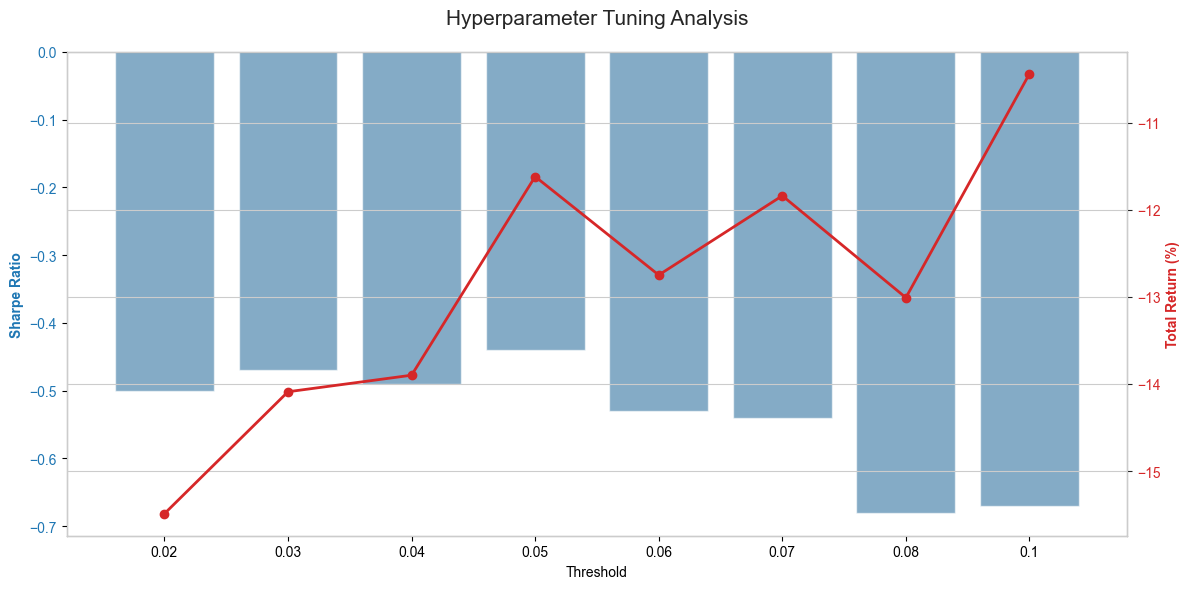

==> Tham số tối ưu chọn theo Sharpe Ratio: 0.05 (Sharpe: -0.44)


In [ ]:
# 1. Khai báo danh sách thử nghiệm
thresholds_to_test = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10]
tuning_data = []

# 2. Chạy vòng lặp để thu thập dữ liệu visualize
for t in thresholds_to_test:
    _, metrics = tester.run_and_evaluate(val_df, MomentumStrategy, f"Val_{t}", threshold=t)
    res = metrics.iloc[0].to_dict()
    res['Threshold'] = t
    tuning_data.append(res)

# 3. Chuyển thành DataFrame
tuning_results_df = pd.DataFrame(tuning_data)

# 4. Visualize
viz = Visualizer()
viz.plot_tuning_results(tuning_results_df)

# 5. In ra tham số tốt nhất
best_t, best_sharpe = tester.find_best_threshold(val_df, MomentumStrategy, thresholds_to_test)
print(f"==> Tham số tối ưu chọn theo Sharpe Ratio: {best_t} (Sharpe: {best_sharpe})")

In [ ]:
# 4. Bước 3: Test (Đánh giá thực tế)
eq_test, m_test = tester.run_and_evaluate(test_df, MomentumStrategy, "Momentum (Test)", threshold=best_t)
display(m_test)

Tham số tối ưu tìm được: 0.05


,Total Return,Sharpe Ratio,Max Drawdown,Final Capital
Momentum (Test),-5.98%,-0.5,-8.58%,"$94,017.31"


In [18]:
# --- BƯỚC 2: TUNE (Sử dụng Heatmap để chọn tham số) ---
# Giả sử bạn đã chạy Grid Search và có tuning_results_df
Visualizer.plot_tuning_heatmap(tuning_results_df)

# --- BƯỚC 3: TEST (So sánh với Benchmark) ---
# Tính Benchmark bằng cách lấy trung bình lợi nhuận tất cả cổ phiếu (Equal Weight)
benchmark_log_ret = test_df['Log Return'].mean(axis=1)
benchmark_equity = np.exp(benchmark_log_ret.cumsum()) * config.initial_capital

# Vẽ biểu đồ đối chiếu thực tế
Visualizer.plot_strategy_vs_benchmark(eq_test, benchmark_equity, title="Final Evaluation: Strategy vs Market")

# Soi rủi ro sụt giảm
Visualizer.plot_underwater(eq_test)

AttributeError: type object 'Visualizer' has no attribute 'plot_tuning_heatmap'

In [14]:
# # Backtest for Momentum Strategy
# tester = Backtester(df, initial_capital=config.initial_capital, 
#                     transaction_cost=config.transaction_cost)

# train_df, val_df, test_df = tester.split_data(train_end=config.train_end, 
#                                               val_end=config.val_end)

# strat_train = MomentumStrategy(train_df) 

# signals_train = strat_train.generate_signals()
# equity_train = tester.run_backtest(train_df, signals_train)

# metrics_train = pd.DataFrame([tester.evaluate(equity_train)])
# metrics_train.index = ["Momentum (Train)"]

# print("--- Kết quả Backtest ---")
# display(metrics_train) 

# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
# plt.plot(equity_train, label='Equity Curve')
# plt.title('Hiệu quả vốn đầu tư (Momentum Strategy)')
# plt.ylabel('Vốn ($)')
# plt.legend()
# plt.grid(True)
# plt.show()

In [15]:
print("Kích thước tập Train:", train_df.shape)
print("Các cột hiện có:", train_df.columns.levels[0].tolist()) 
# Phải có 'Adj Close', 'SMA_50', 'Log Return'
display(train_df.head())

Kích thước tập Train: (2769, 1000)
Các cột hiện có: ['Adj Close', 'Close', 'High', 'Log Return', 'Low', 'Open', 'SMA_200', 'SMA_50', 'Volatility', 'Volume']


Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418381  NaN  18.321968  37.090000  25.670000  9.70  39.311684   
2010-01-05  6.429480  NaN  18.173944  37.700001  25.280001  9.71  38.971138   
2010-01-06  6.327210  NaN  18.274872  37.619999  25.340000  9.57  38.678280   
2010-01-07  6.315514  NaN  18.426273  36.889999  25.480000  9.47  38.324123   
2010-01-08  6.357500  NaN  18.520466  36.689999  26.260000  9.43  38.664646   

                                          ... Volatility                      \
Ticker        AMZN        APD       ASML  ...       UBER  UL UNH UPS   V WFC   
Date                                      ...                                  
2010-01-04  6.6950  51.433220  32.425720  ...        NaN NaN NaN NaN NaN NaN   
2010-01-05  6.7345  51.006466  32.678314  ...        NaN NaN NaN NaN NaN NaN   
2010-01-06  6.6125  50.585888  32.977695  ...        NaN NaN NaN NaN NaN NaN   
2010-01-07  6.5000  50.295200  32.060860  ...        NaN NaN NaN NaN NaN NaN   
2010-01-08  6.6760  50.616821  31.293720  ...        NaN NaN NaN NaN NaN NaN   

                            
Ticker     WMT XOM XYZ YUM  
Date                        
2010-01-04 NaN NaN NaN NaN  
2010-01-05 NaN NaN NaN NaN  
2010-01-06 NaN NaN NaN NaN  
2010-01-07 NaN NaN NaN NaN  
2010-01-08 NaN NaN NaN NaN  

[5 rows x 1000 columns]

In [16]:
# Kiểm tra tên cột của signals
print("Cột của Signals:", signals_train.columns.tolist())

# Kiểm tra tên cột của Log Return
print("Cột của Log Return:", train_df['Log Return'].columns.tolist())

# PHẢI ĐẢM BẢO: Cả hai đều chỉ chứa danh sách Ticker (AAPL, AMZN...) 
# và không có tầng 'Signal' ở trên đầu.

NameError: name 'signals_train' is not defined

In [ ]:
# Tính tổng số lần thay đổi vị thế
total_trades = signals_train.diff().abs().sum().sum()
print(f"Tổng số lệnh thực hiện: {total_trades}")

# Kiểm tra phí trong config
print(f"Phí mỗi lệnh: {config.transaction_cost}")

Tổng số lệnh thực hiện: 36050.0
Phí mỗi lệnh: 0.001


In [ ]:
# # --- GRID SEARCH THRESHOLD TRÊN TẬP VALIDATION ---

# thresholds_to_test = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10]

# best_sharpe = -np.inf
# best_threshold = None

# print(f"{'Threshold':<10} | {'Sharpe':<10} | {'Total Return':<15}")
# print("-" * 45)

# for t in thresholds_to_test:
#     # 1. Strategy trên VALIDATION
#     strategy = MomentumStrategy(val_df, threshold=t)
#     signals = strategy.generate_signals()

#     # 2. Backtest
#     equity = tester.run_backtest(val_df, signals)

#     # 3. Evaluation
#     metrics = tester.evaluate(equity)
#     sharpe = metrics["Sharpe Ratio"]

#     print(f"{t:<10} | {sharpe:<10} | {metrics['Total Return']:<15}")

#     # 4. Save best parameter
#     if sharpe > best_sharpe:
#         best_sharpe = sharpe
#         best_threshold = t

# print("-" * 45)
# print(f"Best threshold on validation set: {best_threshold}")
# print(f"Best Sharpe Ratio: {best_sharpe}")


Threshold  | Sharpe     | Total Return   
---------------------------------------------
0.02       | -0.5       | -15.49%        
0.03       | -0.47      | -14.09%        
0.04       | -0.49      | -13.90%        
0.05       | -0.44      | -11.62%        
0.06       | -0.53      | -12.75%        
0.07       | -0.54      | -11.84%        
0.08       | -0.68      | -13.01%        
0.1        | -0.67      | -10.44%        
---------------------------------------------
Best threshold on validation set: 0.05
Best Sharpe Ratio: -0.44



--- [GIAI ĐOẠN 3] ĐÁNH GIÁ TRÊN TẬP TEST (DỮ LIỆU CHƯA THẤY) ---


,Total Return,Sharpe Ratio,Max Drawdown,Final Capital
"Momentum Final (Test, Threshold=0.05)",-5.98%,-0.5,-8.58%,"$94,017.31"


NameError: name 'equity_val' is not defined

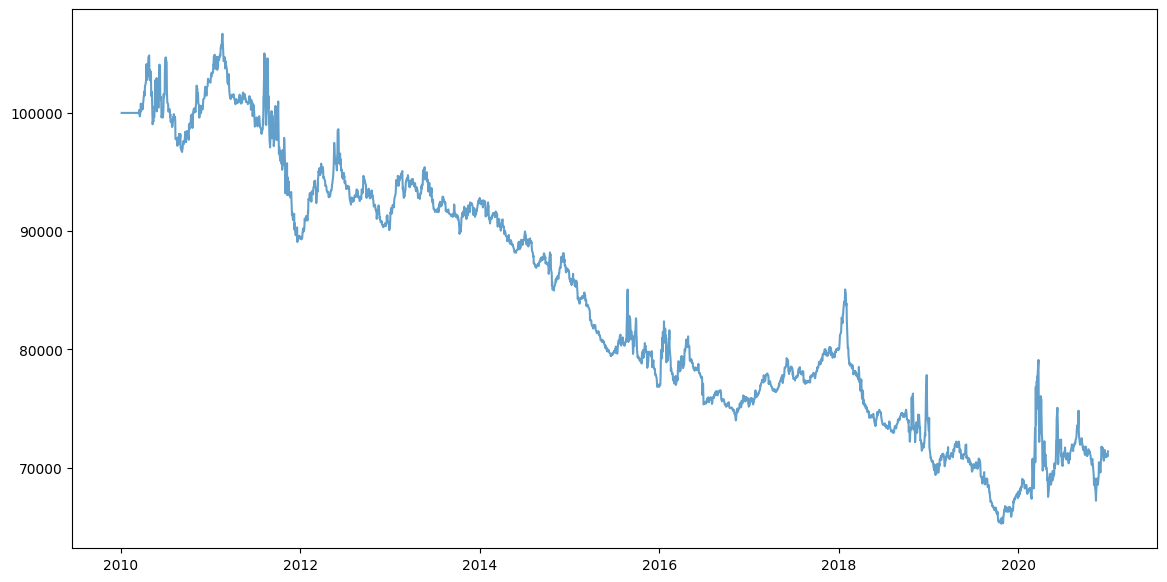

In [ ]:
# # --- BƯỚC 3: ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (FINAL EVALUATION) ---
# # Tài liệu yêu cầu: Chỉ thực hiện khi đã chốt tham số tối ưu

# print("\n--- [GIAI ĐOẠN 3] ĐÁNH GIÁ TRÊN TẬP TEST (DỮ LIỆU CHƯA THẤY) ---")

# # 1. Sử dụng tham số tốt nhất (best_threshold = 0.05) vừa tìm được từ tập Validation
# strat_test = MomentumStrategy(test_df, threshold=best_threshold)
# signals_test = strat_test.generate_signals()

# # 2. Chạy backtest trên tập TEST - Đây là kết quả thực tế khách quan nhất
# equity_test = tester.run_backtest(test_df, signals_test)

# # 3. Tính toán các chỉ số hiệu suất cuối cùng
# metrics_final = tester.evaluate(equity_test)
# df_metrics_final = pd.DataFrame([metrics_final])
# df_metrics_final.index = [f"Momentum Final (Test, Threshold={best_threshold})"]

# display(df_metrics_final)

# # --- TRỰC QUAN HÓA SO SÁNH (VISUALIZATION) ---
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 7))
# # Vẽ cả 3 giai đoạn để so sánh tính nhất quán
# plt.plot(equity_train, label='1. Train Set (Earliest)', alpha=0.7)
# plt.plot(equity_val, label='2. Validation Set (Tuning)', alpha=0.7)
# plt.plot(equity_test, label='3. Test Set (Final Evaluation)', linewidth=2.5, color='red')

# plt.title('So sánh hiệu quả vốn qua 3 giai đoạn (Workflow chuẩn)')
# plt.ylabel('Vốn ($)')
# plt.legend()
# plt.grid(True)
# plt.show()